---
# 🐔 La Poule Qui Chante
### Étude de marché international — Poulets Agriculture Biologique
#### Notebook 1 — Préparation et nettoyage des données
---

## Contexte

**La Poule Qui Chante** est une entreprise française spécialisée dans la production de **poulets biologiques**.
Elle souhaite identifier les pays les plus prometteurs pour exporter ses produits.

Pour cela, nous allons construire un jeu de données propre et complet à partir de **7 sources ouvertes** :
- **FAO** : disponibilité alimentaire et population mondiale
- **Banque Mondiale** : PIB par habitant, population urbaine, indice de gouvernance
- **Heritage Foundation** : liberté du commerce
- **FiBL** : part de l'agriculture biologique

Ce notebook couvre la **Phase 1** : chargement, nettoyage, feature engineering et export du dataset final.

---

## 1) Imports et paramètres d'affichage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

print("✅ Imports OK — bibliothèques chargées avec succès")

✅ Imports OK — bibliothèques chargées avec succès


---
## 2) Chargement des fichiers sources

Nous avons **7 fichiers CSV** à charger. Chacun correspond à une source de données différente.

Attention : certains utilisent le séparateur `;` (format français), d'autres la virgule `,`.

In [2]:
# Importation du fichier Population_2000_2018.csv
fao_pop = pd.read_csv('Population_2000_2018.csv', sep=';', encoding='utf-8')

# Importation du fichier DisponibiliteAlimentaire_2017.csv
fao_food = pd.read_csv('DisponibiliteAlimentaire_2017.csv', sep=';', encoding='utf-8')

# Importation du fichier wb_gdp_per_capita_2017.csv
wb_gdp = pd.read_csv('wb_gdp_per_capita_2017.csv', sep=';', encoding='utf-8')

# Importation du fichier wb_urban_pop_2017.csv
wb_urb = pd.read_csv('wb_urban_pop_2017.csv', sep=';', encoding='utf-8')

# Importation du fichier wb_indice_gouvernance_2017_clean.csv
wb_gov = pd.read_csv('wb_indice_gouvernance_2017_clean.csv', sep=';', encoding='utf-8')

# Importation du fichier heritage_trade_freedom_2017.csv
heritage = pd.read_csv('heritage_trade_freedom_2017.csv', sep=';', encoding='utf-8')

# Importation du fichier fibl_surface_agri_bio_2017_pct.csv
fibl = pd.read_csv('fibl_surface_agri_bio_2017_pct.csv', sep=';', encoding='utf-8')

print('✅ Tous les fichiers sont chargés.')


✅ Tous les fichiers sont chargés.


In [3]:
print("=== Aperçu fao_pop ===")
display(fao_pop.head(3))

print("=== Aperçu fao_food ===")
display(fao_food.head(3))

print("=== Aperçu wb_gdp ===")
display(wb_gdp.head(3))

print("=== Aperçu wb_urb ===")
display(wb_urb.head(3))

print("=== Aperçu wb_gov ===")
display(wb_gov.head(3))

print("=== Aperçu heritage ===")
display(heritage.head(3))

print("=== Aperçu fibl ===")
display(fibl.head(3))

=== Aperçu fao_pop ===


,Code Domaine,Domaine,Code zone,iso3,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN


=== Aperçu fao_food ===


,Code Domaine,Domaine,Code zone,iso3,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,AFG,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,AFG,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,AFG,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées


=== Aperçu wb_gdp ===


...

,iso3,country_clean,governance_index_mean
0,AFG,Afghanistan,"-1,60779798"
1,ALB,Albania,"0,000206777"
2,DZA,Algeria,"-0,860526711"


=== Aperçu heritage ===


,iso3,country_clean,Trade Freedom
0,AFG,Afghanistan,66.0
1,ALB,Albania,87.7
2,DZA,Algeria,63.3


=== Aperçu fibl ===


,country_clean,iso3,organic_agri_share_pct
0,Afghanistan,AFG,0
1,Albania,ALB,"0,05"
2,Algeria,DZA,0


---
## 3) Nettoyage et typage des données

Les fichiers viennent de sources différentes :
- certains nombres utilisent une **virgule** comme séparateur décimal (`1,5` au lieu de `1.5`)
- il peut y avoir des **espaces** parasites dans les colonnes texte
- un même pays peut apparaître **plusieurs fois** (doublons à supprimer)

In [4]:
# 3.a — Renommer 'Trade Freedom' en snake_case
if "Trade Freedom" in heritage.columns:
    heritage = heritage.rename(columns={"Trade Freedom": "trade_freedom_2017"})
    print("✅ Renommé : 'Trade Freedom' → 'trade_freedom_2017'")
print("Colonnes heritage :", list(heritage.columns))

✅ Renommé : 'Trade Freedom' → 'trade_freedom_2017'
Colonnes heritage : ['iso3', 'country_clean', 'trade_freedom_2017']


In [5]:
# 3.b — Convertir les nombres qui utilisent une virgule décimale (ex : '1,5' → 1.5)
# On remplace manuellement les virgules par des points, puis on convertit en nombre

# Pour wb_gov
wb_gov["governance_index_mean"] = (
    wb_gov["governance_index_mean"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
)
wb_gov["governance_index_mean"] = pd.to_numeric(wb_gov["governance_index_mean"], errors="coerce")

# Pour fibl
fibl["organic_agri_share_pct"] = (
    fibl["organic_agri_share_pct"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
)
fibl["organic_agri_share_pct"] = pd.to_numeric(fibl["organic_agri_share_pct"], errors="coerce")

print("✅ Conversion terminée")
print(wb_gov["governance_index_mean"].describe())
print(fibl["organic_agri_share_pct"].describe())


✅ Conversion terminée
count    202.000
mean      -0.020
std        0.922
min       -2.112
25%       -0.657
50%       -0.155
75%        0.638
max        1.835
Name: governance_index_mean, dtype: float64
count    168.000
mean       3.005
std        5.847
min        0.000
25%        0.107
50%        0.640
75%        3.143
max       38.740
Name: organic_agri_share_pct, dtype: float64


In [6]:
# 3.c — Supprimer les espaces en trop dans les colonnes texte

# On applique .strip() sur chaque colonne 'country_clean' et 'iso3' quand elles existent

if "country_clean" in wb_gdp.columns:
    wb_gdp["country_clean"] = wb_gdp["country_clean"].astype(str).str.strip()
if "iso3" in wb_gdp.columns:
    wb_gdp["iso3"] = wb_gdp["iso3"].astype(str).str.strip()

if "country_clean" in wb_urb.columns:
    wb_urb["country_clean"] = wb_urb["country_clean"].astype(str).str.strip()
if "iso3" in wb_urb.columns:
    wb_urb["iso3"] = wb_urb["iso3"].astype(str).str.strip()

if "country_clean" in wb_gov.columns:
    wb_gov["country_clean"] = wb_gov["country_clean"].astype(str).str.strip()
if "iso3" in wb_gov.columns:
    wb_gov["iso3"] = wb_gov["iso3"].astype(str).str.strip()

if "country_clean" in heritage.columns:
    heritage["country_clean"] = heritage["country_clean"].astype(str).str.strip()
if "iso3" in heritage.columns:
    heritage["iso3"] = heritage["iso3"].astype(str).str.strip()

if "country_clean" in fibl.columns:
    fibl["country_clean"] = fibl["country_clean"].astype(str).str.strip()
if "iso3" in fibl.columns:
    fibl["iso3"] = fibl["iso3"].astype(str).str.strip()

print("✅ Espaces nettoyés")


✅ Espaces nettoyés


In [7]:
# 3.d — Supprimer les doublons sur la colonne iso3 (on veut une seule ligne par pays)

avant = wb_gdp.shape[0]
wb_gdp = wb_gdp.drop_duplicates(subset=["iso3"], keep="first")
print(f"wb_gdp   : {avant} → {wb_gdp.shape[0]} lignes")

avant = wb_urb.shape[0]
wb_urb = wb_urb.drop_duplicates(subset=["iso3"], keep="first")
print(f"wb_urb   : {avant} → {wb_urb.shape[0]} lignes")

avant = wb_gov.shape[0]
wb_gov = wb_gov.drop_duplicates(subset=["iso3"], keep="first")
print(f"wb_gov   : {avant} → {wb_gov.shape[0]} lignes")

avant = heritage.shape[0]
heritage = heritage.drop_duplicates(subset=["iso3"], keep="first")
print(f"heritage : {avant} → {heritage.shape[0]} lignes")

avant = fibl.shape[0]
fibl = fibl.drop_duplicates(subset=["iso3"], keep="first")
print(f"fibl     : {avant} → {fibl.shape[0]} lignes")


wb_gdp   : 210 → 210 lignes
wb_urb   : 215 → 215 lignes
wb_gov   : 202 → 202 lignes
heritage : 185 → 185 lignes
fibl     : 169 → 164 lignes


---
## 4) Exploration des données FAO — Volaille

La base FAO est structurée en lignes longues (un couple pays/produit/élément par ligne).
On va identifier les produits et éléments liés à la volaille, puis les extraire.

In [8]:
# Sous-ensemble 2017 uniquement
fao_2017 = fao_food[fao_food["Code année"] == 2017].copy()

print(f"Lignes en 2017       : {len(fao_2017)}")
print(f"Pays distincts       : {fao_2017['iso3'].nunique()}")
print(f"Produits distincts   : {fao_2017['Produit'].nunique()}")
print(f"Éléments distincts   : {fao_2017['Élément'].nunique()}")

Lignes en 2017       : 176600
Pays distincts       : 174
Produits distincts   : 98
Éléments distincts   : 17


In [9]:
# Produits liés à la volaille
masque_vol = fao_2017["Produit"].str.contains("volaille|poulet|poultry", case=False, na=False)
print("🐔 Produits volaille trouvés :")
for p in sorted(fao_2017.loc[masque_vol, "Produit"].unique()):
    print(" -", p)

print("\n📦 Éléments disponibles pour ces produits :")
for e in sorted(fao_2017.loc[masque_vol, "Élément"].unique()):
    print(" -", e)

🐔 Produits volaille trouvés :
 - Viande de Volailles

📦 Éléments disponibles pour ces produits :
 - Alimentation pour touristes
 - Aliments pour animaux
 - Autres utilisations (non alimentaire)
 - Disponibilité alimentaire (Kcal/personne/jour)
 - Disponibilité alimentaire en quantité (kg/personne/an)
 - Disponibilité de matière grasse en quantité (g/personne/jour)
 - Disponibilité de protéines en quantité (g/personne/jour)
 - Disponibilité intérieure
 - Exportations - Quantité
 - Importations - Quantité
 - Nourriture
 - Pertes
 - Production
 - Résidus
 - Semences
 - Traitement
 - Variation de stock


In [10]:
import unicodedata

# Cette fonction supprime les accents et met en minuscules
# Elle sert à comparer des textes sans se soucier des accents ou majuscules
def normaliser_texte(texte):
    texte = unicodedata.normalize("NFKD", str(texte))
    texte = texte.encode("ascii", "ignore").decode("ascii")
    return texte.lower().strip()

# On applique cette fonction sur les colonnes Élément et Produit
fao_2017["elem_n"] = fao_2017["Élément"].apply(normaliser_texte)
fao_2017["prod_n"] = fao_2017["Produit"].apply(normaliser_texte)

# On crée des masques (filtres) pour chaque type d'information
est_volaille   = fao_2017["prod_n"].str.contains("volaille|poulet|poultry")
est_production = fao_2017["elem_n"].str.contains(r"\bproduction\b")
est_import_qte = fao_2017["elem_n"].str.contains("import") & fao_2017["elem_n"].str.contains("quant")
est_export_qte = fao_2017["elem_n"].str.contains("export") & fao_2017["elem_n"].str.contains("quant")
est_kcal       = fao_2017["elem_n"].str.contains("kcal")

col_val = "Valeur"

# Pour chaque type, on regroupe par pays (iso3) et on additionne les valeurs
prod_vol = fao_2017[est_production & est_volaille].groupby("iso3", as_index=False)[col_val].sum()
prod_vol = prod_vol.rename(columns={col_val: "production_volaille"})

imp_vol = fao_2017[est_import_qte & est_volaille].groupby("iso3", as_index=False)[col_val].sum()
imp_vol = imp_vol.rename(columns={col_val: "import_volaille"})

exp_vol = fao_2017[est_export_qte & est_volaille].groupby("iso3", as_index=False)[col_val].sum()
exp_vol = exp_vol.rename(columns={col_val: "export_volaille"})

kcal_vol = fao_2017[est_kcal & est_volaille].groupby("iso3", as_index=False)[col_val].sum()
kcal_vol = kcal_vol.rename(columns={col_val: "dispo_volaille_kcal_jour"})

print(f"Production : {len(prod_vol)} pays | Import : {len(imp_vol)} | Export : {len(exp_vol)} | Kcal : {len(kcal_vol)}")


Production : 168 pays | Import : 170 | Export : 135 | Kcal : 172


---
## 5) Feature Engineering 1 — Croissance démographique 2000–2017

**Formule** : `(pop_2017 - pop_2000) / pop_2000 × 100`

Un pays à forte croissance démographique est un marché en expansion — pertinent pour notre étude.

In [11]:
fao_pop_sub = fao_pop[fao_pop["Code année"].isin([2000, 2017])].copy()

pop_pivot = (
    fao_pop_sub
    .pivot_table(index="iso3", columns="Code année", values="Valeur", aggfunc="first")
    .rename(columns={2000: "pop_2000", 2017: "pop_2017"})
    .reset_index()
)

# FAO exprime en milliers → conversion en habitants
pop_pivot["pop_2000"] = pd.to_numeric(pop_pivot["pop_2000"], errors="coerce") * 1_000
pop_pivot["pop_2017"] = pd.to_numeric(pop_pivot["pop_2017"], errors="coerce") * 1_000

pop_pivot["population_growth_2000_2017_pct"] = np.where(
    pop_pivot["pop_2000"] > 0,
    (pop_pivot["pop_2017"] - pop_pivot["pop_2000"]) / pop_pivot["pop_2000"] * 100,
    np.nan
)

print("✅ Nouvelle variable : population_growth_2000_2017_pct")
print(pop_pivot["population_growth_2000_2017_pct"].describe())
display(pop_pivot.nlargest(5, "population_growth_2000_2017_pct")[["iso3","pop_2017","population_growth_2000_2017_pct"]])

✅ Nouvelle variable : population_growth_2000_2017_pct
count    224.000
mean      29.485
std       37.078
min      -19.015
25%        6.831
50%       22.228
75%       46.154
max      359.895
Name: population_growth_2000_2017_pct, dtype: float64


Code année,iso3,pop_2017,population_growth_2000_2017_pct
174,QAT,2.725e+06,359.895
6,ARE,9.487e+06,202.713
21,BHR,1.494e+06,124.805
81,GNQ,1.262e+06,108.189
160,OMN,4.666e+06,105.731


---
## 6) Fusion finale des sources (clé = iso3)

In [12]:
# 6.a — Label pays (nom lisible) depuis FAO
label_fao = (
    fao_pop[["iso3", "Zone"]]
    .drop_duplicates("iso3")
    .rename(columns={"Zone": "country_label"})
)
print(f"Labels pays : {len(label_fao)}")
display(label_fao.head(3))

Labels pays : 234


,iso3,country_label
0,AFG,Afghanistan
19,ZAF,Afrique du Sud
38,ALB,Albanie


In [13]:
# 6.b — Versions slim de chaque source
gdp_slim = wb_gdp[["iso3", "gdp_per_capita_2017_usd"]]
urb_slim = wb_urb[["iso3", "urban_pop_2017_pct"]]
gov_slim = wb_gov[["iso3", "governance_index_mean"]]
trd_slim = heritage[["iso3", "trade_freedom_2017"]]
bio_slim = fibl[["iso3", "organic_agri_share_pct"]]

# Table FAO volaille consolidée
fao_vol = (
    prod_vol
    .merge(imp_vol,  on="iso3", how="outer")
    .merge(exp_vol,  on="iso3", how="outer")
    .merge(kcal_vol, on="iso3", how="outer")
)
print(f"Table FAO volaille : {fao_vol.shape}")
display(fao_vol.head(4))

Table FAO volaille : (172, 5)


,iso3,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
0,AFG,28.0,29.0,NaN,5.0
1,AGO,42.0,277.0,0.0,35.0
2,ALB,13.0,38.0,0.0,85.0
3,ARE,48.0,433.0,94.0,147.0


In [14]:
# 6.c — Fusion progressive (LEFT JOIN sur iso3)
base = pop_pivot.copy()
base = base.merge(label_fao, on="iso3", how="left")
base = base.merge(gdp_slim,  on="iso3", how="left")
base = base.merge(urb_slim,  on="iso3", how="left")
base = base.merge(gov_slim,  on="iso3", how="left")
base = base.merge(trd_slim,  on="iso3", how="left")
base = base.merge(bio_slim,  on="iso3", how="left")
base = base.merge(fao_vol,   on="iso3", how="left")

# 6.d — Réordonner les colonnes
ordre = [
    "iso3", "country_label",
    "pop_2000", "pop_2017", "population_growth_2000_2017_pct",
    "gdp_per_capita_2017_usd", "urban_pop_2017_pct",
    "governance_index_mean", "trade_freedom_2017", "organic_agri_share_pct",
    "production_volaille", "import_volaille", "export_volaille", "dispo_volaille_kcal_jour",
]
base = base[[c for c in ordre if c in base.columns]]

print(f"✅ Dataset fusionné : {base.shape}")
display(base.head(5))

✅ Dataset fusionné : (233, 14)


,iso3,country_label,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
0,ABW,Aruba,9.085e+04,1.054e+05,15.974,28440.052,43.293,1.200e+00,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,2.078e+07,3.630e+07,74.669,525.470,25.250,-1.608e+00,66.0,0.00,28.0,29.0,NaN,5.0
2,AGO,Angola,1.640e+07,2.982e+07,81.860,2437.260,64.839,-9.943e-01,56.7,NaN,42.0,277.0,0.0,35.0
3,AIA,Anguilla,1.125e+04,1.458e+04,29.613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ALB,Albanie,3.129e+06,2.884e+06,-7.832,4614.048,59.383,2.068e-04,87.7,0.05,13.0,38.0,0.0,85.0


---
## 7) Traitement des valeurs manquantes — Export volaille

### Diagnostic des NaN par colonne

In [15]:
# Taux de NaN par colonne
nan_col = (base.isna().mean() * 100).round(1)
print("Taux de valeurs manquantes (%) par colonne :")
display(nan_col.to_frame("missing_%"))

# Focus sur export_volaille
n_nan_export = base["export_volaille"].isna().sum()
print(f"\n⚠️  export_volaille : {n_nan_export} valeurs manquantes")

Taux de valeurs manquantes (%) par colonne :


,missing_%
iso3,0.0
country_label,0.0
pop_2000,3.9
pop_2017,0.0
population_growth_2000_2017_pct,3.9
gdp_per_capita_2017_usd,10.7
urban_pop_2017_pct,8.2
governance_index_mean,13.7
trade_freedom_2017,21.9
organic_agri_share_pct,30.5



⚠️  export_volaille : 98 valeurs manquantes


### Imputation des exports manquants → 0

**Hypothèse retenue** : si un pays n'a pas de valeur d'exportation de volaille dans la base FAO,
c'est très probablement parce qu'il **n'exporte pas du tout**, et non parce que la donnée est inconnue.

Cette hypothèse est cohérente avec le fait que :
- les données FAO sont très exhaustives pour 2017
- les pays non-exportateurs n'ont tout simplement pas de ligne dans la table export

On **impute donc ces NaN par 0**. Cette décision sera documentée et justifiable auprès du mentor.

In [16]:
# Affichage des pays concernés par les NaN export avant imputation
pays_nan_export = base[base["export_volaille"].isna()][["iso3", "country_label", "import_volaille", "export_volaille"]]
print(f"Pays avec export_volaille = NaN ({len(pays_nan_export)} pays) :")
display(pays_nan_export.head(20))

Pays avec export_volaille = NaN (98 pays) :


,iso3,country_label,import_volaille,export_volaille
0,ABW,Aruba,NaN,NaN
1,AFG,Afghanistan,29.0,NaN
3,AIA,Anguilla,NaN,NaN
5,AND,Andorre,NaN,NaN
9,ASM,Samoa américaines,NaN,NaN
14,BDI,Burundi,NaN,NaN
17,BES,"Bonaire, Saint-Eustache et Saba",NaN,NaN
18,BFA,Burkina Faso,0.0,NaN
19,BGD,Bangladesh,0.0,NaN
21,BHR,Bahreïn,NaN,NaN


In [17]:
# Imputation : NaN export → 0 (non-exportateurs)
base["export_volaille"] = base["export_volaille"].fillna(0)

# Vérification
print(f"✅ Après imputation — NaN dans export_volaille : {base['export_volaille'].isna().sum()}")
print(f"   Pays avec export = 0 : {(base['export_volaille'] == 0).sum()}")
print()
print("💡 Ces pays importent de la volaille sans en exporter — cibles potentielles pour La Poule Qui Chante.")

✅ Après imputation — NaN dans export_volaille : 0
   Pays avec export = 0 : 150

💡 Ces pays importent de la volaille sans en exporter — cibles potentielles pour La Poule Qui Chante.


---
## 8) Analyse exploratoire — Statistiques descriptives et outliers

In [18]:
print("Types des variables :")
print(base.dtypes)
print(f"\nNombre total de pays dans le dataset : {len(base)}")

Types des variables :
iso3                                object
country_label                       object
pop_2000                           float64
pop_2017                           float64
population_growth_2000_2017_pct    float64
gdp_per_capita_2017_usd            float64
urban_pop_2017_pct                 float64
governance_index_mean              float64
trade_freedom_2017                 float64
organic_agri_share_pct             float64
production_volaille                float64
import_volaille                    float64
export_volaille                    float64
dispo_volaille_kcal_jour           float64
dtype: object

Nombre total de pays dans le dataset : 233


In [19]:
# Statistiques descriptives + taux de NaN
desc = base.describe().T
desc["missing_%"] = (base.isna().mean() * 100).round(1)
display(desc)

,count,mean,std,min,25%,50%,75%,max,missing_%
pop_2000,224.0,2.723e+07,1.151e+08,785.000,407906.250,4.464e+06,1.604e+07,1.291e+09,3.9
pop_2017,233.0,3.239e+07,1.327e+08,793.000,424473.000,5.448e+06,1.965e+07,1.421e+09,0.0
population_growth_2000_2017_pct,224.0,2.948e+01,3.708e+01,-19.015,6.831,2.223e+01,4.615e+01,3.599e+02,3.9
gdp_per_capita_2017_usd,208.0,1.796e+04,2.614e+04,236.694,2349.236,6.583e+03,2.346e+04,1.707e+05,10.7
urban_pop_2017_pct,214.0,6.065e+01,2.398e+01,12.706,41.706,6.160e+01,8.016e+01,1.000e+02,8.2
governance_index_mean,201.0,-2.657e-02,9.204e-01,-2.112,-0.658,-1.560e-01,6.299e-01,1.835e+00,13.7
trade_freedom_2017,182.0,7.596e+01,1.190e+01,0.000,69.250,7.845e+01,8.647e+01,9.000e+01,21.9
organic_agri_share_pct,162.0,3.023e+00,5.923e+00,0.000,0.103,6.300e-01,3.147e+00,3.874e+01,30.5
production_volaille,168.0,7.252e+02,2.501e+03,0.000,13.750,7.000e+01,4.098e+02,2.191e+04,27.9
import_volaille,170.0,8.953e+01,1.867e+02,0.000,3.000,1.600e+01,8.125e+01,1.069e+03,27.0


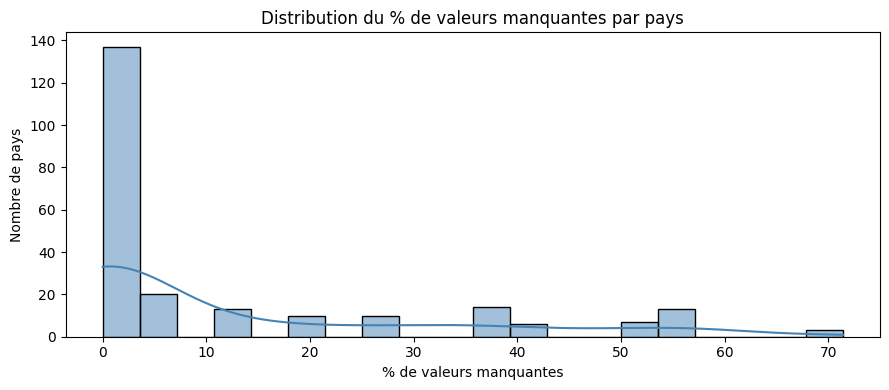

count    233.000
mean      12.416
std       19.101
min        0.000
25%        0.000
50%        0.000
75%       21.429
max       71.429
Name: missing_pct, dtype: float64


In [20]:
# Distribution des valeurs manquantes par pays
base["missing_pct"] = base.isna().mean(axis=1) * 100

plt.figure(figsize=(9, 4))
sns.histplot(base["missing_pct"], bins=20, kde=True, color="steelblue")
plt.title("Distribution du % de valeurs manquantes par pays")
plt.xlabel("% de valeurs manquantes")
plt.ylabel("Nombre de pays")
plt.tight_layout()
plt.show()
print(base["missing_pct"].describe())

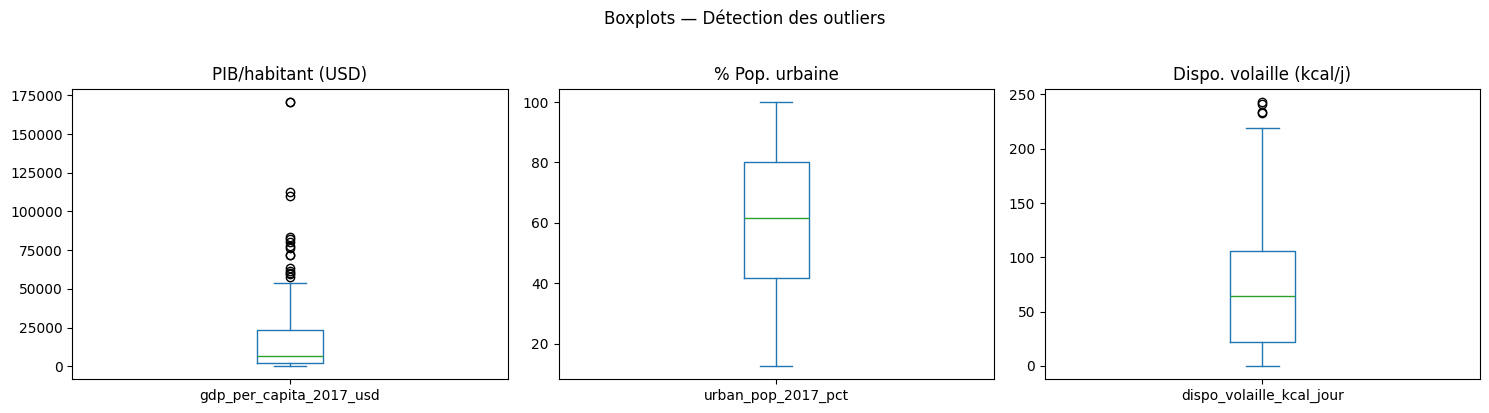

💡 Les points hors moustaches sont des outliers. On les conserve : ils reflètent des réalités économiques réelles.


In [21]:
# Boxplots — détection des outliers sur 3 variables clés
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vars_box = [
    ("gdp_per_capita_2017_usd", "PIB/habitant (USD)"),
    ("urban_pop_2017_pct",       "% Pop. urbaine"),
    ("dispo_volaille_kcal_jour", "Dispo. volaille (kcal/j)"),
]
for ax, (col, titre) in zip(axes, vars_box):
    if col in base.columns:
        base[col].dropna().plot.box(ax=ax)
        ax.set_title(titre)

plt.suptitle("Boxplots — Détection des outliers", y=1.02)
plt.tight_layout()
plt.show()

print("💡 Les points hors moustaches sont des outliers. On les conserve : ils reflètent des réalités économiques réelles.")

In [22]:
# Identification des outliers PIB (méthode IQR)
q1 = base["gdp_per_capita_2017_usd"].quantile(0.25)
q3 = base["gdp_per_capita_2017_usd"].quantile(0.75)
borne_sup = q3 + 1.5 * (q3 - q1)

outliers = base[base["gdp_per_capita_2017_usd"] > borne_sup][
    ["iso3", "country_label", "gdp_per_capita_2017_usd"]
].sort_values("gdp_per_capita_2017_usd", ascending=False)

print(f"Pays avec PIB > {borne_sup:,.0f} USD (outliers) :")
display(outliers)
print("→ Pays pétroliers ou places financières. Conservés dans l'analyse.")

Pays avec PIB > 55,125 USD (outliers) :


,iso3,country_label,gdp_per_capita_2017_usd
128,MCO,Monaco,170663.375
119,LIE,Liechtenstein,170547.092
27,BMU,Bermudes,112339.426
123,LUX,Luxembourg,110193.214
95,IMN,Île de Man,83481.304
36,CHE,Suisse,82254.377
50,CYM,Îles Caïmanes,80053.944
125,MAC,Chine - RAS de Macao,77704.922
156,NOR,Norvège,76131.838
97,IRL,Irlande,72198.108


→ Pays pétroliers ou places financières. Conservés dans l'analyse.


---
## 9) Filtrage — Suppression des pays avec valeurs manquantes

Pour que l'ACP fonctionne, **aucune valeur manquante n'est tolérée**.
On filtre les pays incomplets, puis on vérifie qu'il reste **au moins 100 pays** (critère de la fiche).

In [23]:
df_complet = base[base["missing_pct"] == 0].copy()
df_complet = df_complet.drop(columns=["missing_pct"])

print(f"Pays conservés : {len(df_complet)} sur {len(base)} ({len(df_complet)/len(base)*100:.1f} %)")

# Couverture population mondiale
pop_totale  = base["pop_2017"].sum()
pop_filtree = df_complet["pop_2017"].sum()
print(f"🌍 Couverture pop. mondiale : {pop_filtree/pop_totale*100:.1f} %")

# -------------------------------------------------------
# ✅ CRITÈRE FICHE : au moins 100 pays
# -------------------------------------------------------
assert len(df_complet) >= 100, f"❌ Seulement {len(df_complet)} pays — en dessous du minimum de 100 !"
print(f"\n✅ CRITÈRE RESPECTÉ : {len(df_complet)} pays ≥ 100 pays requis")

display(df_complet.head(6))

Pays conservés : 137 sur 233 (58.8 %)
🌍 Couverture pop. mondiale : 93.3 %

✅ CRITÈRE RESPECTÉ : 137 pays ≥ 100 pays requis


,iso3,country_label,pop_2000,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,production_volaille,import_volaille,export_volaille,dispo_volaille_kcal_jour
1,AFG,Afghanistan,2.078e+07,3.630e+07,74.669,525.470,25.250,-1.608e+00,66.0,0.00,28.0,29.0,0.0,5.0
4,ALB,Albanie,3.129e+06,2.884e+06,-7.832,4614.048,59.383,2.068e-04,87.7,0.05,13.0,38.0,0.0,85.0
6,ARE,Émirats arabes unis,3.134e+06,9.487e+06,202.713,42340.592,86.248,6.299e-01,83.5,1.10,48.0,433.0,94.0,147.0
7,ARG,Argentine,3.687e+07,4.394e+07,19.165,14532.501,91.749,1.393e-02,66.7,3.04,2161.0,8.0,207.0,182.0
8,ARM,Arménie,3.070e+06,2.945e+06,-4.066,3869.054,63.103,-3.427e-01,80.2,0.09,11.0,35.0,0.0,54.0
11,AUS,Australie,1.899e+07,2.458e+07,29.451,53901.715,85.904,1.513e+00,86.2,9.59,1269.0,16.0,42.0,192.0


In [24]:
df_complet.to_csv("P11_dataset_complet.csv", index=False, encoding="utf-8")
print("💾 Exporté : P11_dataset_complet.csv")

💾 Exporté : P11_dataset_complet.csv


---
## 10) Feature Engineering 2 — Variables par habitant

La Chine et le Luxembourg ne sont pas comparables en volume absolu.
On **ramène les volumes à la population** pour corriger l'effet taille.

3 nouvelles variables :
- `production_volaille_per_million` : tonnes produites par million d'habitants
- `export_volaille_per_million` : tonnes exportées par million d'habitants
- `import_volaille_per_million` : tonnes importées par million d'habitants

In [25]:
df_clean = df_complet.copy()
df_clean = df_clean.rename(columns={"country_label": "country"})

df_clean["production_volaille_per_million"] = df_clean["production_volaille"] / df_clean["pop_2017"] * 1_000_000
df_clean["export_volaille_per_million"]     = df_clean["export_volaille"]     / df_clean["pop_2017"] * 1_000_000
df_clean["import_volaille_per_million"]     = df_clean["import_volaille"]     / df_clean["pop_2017"] * 1_000_000

print("✅ 3 nouvelles variables créées (par million d'habitants)")
display(
    df_clean[["country", "pop_2017", "production_volaille", "production_volaille_per_million"]]
    .sort_values("production_volaille_per_million", ascending=False)
    .head(10)
)

✅ 3 nouvelles variables créées (par million d'habitants)


,country,pop_2017,production_volaille,production_volaille_per_million
101,Israël,8.244e+06,629.0,76.299
29,Brésil,2.078e+08,14201.0,68.329
218,États-Unis d'Amérique,3.251e+08,21914.0,67.410
155,Pays-Bas,1.702e+07,1100.0,64.625
167,Pologne,3.795e+07,2351.0,61.945
147,Malaisie,3.110e+07,1724.0,55.426
26,Belize,3.758e+05,20.0,53.224
11,Australie,2.458e+07,1269.0,51.618
93,Hongrie,9.730e+06,493.0,50.669
7,Argentine,4.394e+07,2161.0,49.184


In [26]:
# Suppression des colonnes redondantes / inutiles pour l'ACP
df_clean = df_clean.drop(columns=[
    "production_volaille",  # remplacée
    "export_volaille",      # remplacée
    "import_volaille",      # remplacée
    "pop_2000",             # déjà utilisée pour le taux de croissance
    "iso3",                 # identifiant, non numérique
])

print(f"Dataset après feature engineering : {df_clean.shape[0]} pays × {df_clean.shape[1]} variables")
print("Variables conservées :")
print(df_clean.columns.tolist())

Dataset après feature engineering : 137 pays × 12 variables
Variables conservées :
['country', 'pop_2017', 'population_growth_2000_2017_pct', 'gdp_per_capita_2017_usd', 'urban_pop_2017_pct', 'governance_index_mean', 'trade_freedom_2017', 'organic_agri_share_pct', 'dispo_volaille_kcal_jour', 'production_volaille_per_million', 'export_volaille_per_million', 'import_volaille_per_million']


---
## 11) Matrice des corrélations (Heatmap)

Avant de passer à l'ACP, on examine les **corrélations entre variables numériques**.

**Pourquoi ?** Si deux variables sont très fortement corrélées (r > 0.9 ou < -0.9),
elles apportent la même information. On peut en retirer une sans perte.

Cela évite la **redondance** dans le modèle et améliore la lisibilité de l'ACP.

In [27]:
# On sélectionne uniquement les colonnes numériques (on exclut 'country')
cols_num = df_clean.select_dtypes(include="number").columns.tolist()
print(f"Variables numériques ({len(cols_num)}) : {cols_num}")

# Calcul de la matrice de corrélations de Pearson
corr_matrix = df_clean[cols_num].corr()

print("\nMatrice de corrélations (aperçu) :")
display(corr_matrix.round(2))

Variables numériques (11) : ['pop_2017', 'population_growth_2000_2017_pct', 'gdp_per_capita_2017_usd', 'urban_pop_2017_pct', 'governance_index_mean', 'trade_freedom_2017', 'organic_agri_share_pct', 'dispo_volaille_kcal_jour', 'production_volaille_per_million', 'export_volaille_per_million', 'import_volaille_per_million']

Matrice de corrélations (aperçu) :


,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
pop_2017,1.00,-0.05,-0.06,-0.07,-0.08,-0.10,-0.10,-0.06,-0.02,-0.04,-0.15
population_growth_2000_2017_pct,-0.05,1.00,-0.16,-0.21,-0.36,-0.34,-0.27,-0.21,-0.34,-0.21,0.01
gdp_per_capita_2017_usd,-0.06,-0.16,1.00,0.59,0.82,0.50,0.31,0.38,0.33,0.32,0.23
urban_pop_2017_pct,-0.07,-0.21,0.59,1.00,0.58,0.40,0.11,0.59,0.53,0.30,0.22
governance_index_mean,-0.08,-0.36,0.82,0.58,1.00,0.61,0.48,0.47,0.41,0.37,0.33
trade_freedom_2017,-0.10,-0.34,0.50,0.40,0.61,1.00,0.25,0.28,0.37,0.29,0.03
organic_agri_share_pct,-0.10,-0.27,0.31,0.11,0.48,0.25,1.00,0.15,0.01,0.13,0.37
dispo_volaille_kcal_jour,-0.06,-0.21,0.38,0.59,0.47,0.28,0.15,1.00,0.72,0.15,0.39
production_volaille_per_million,-0.02,-0.34,0.33,0.53,0.41,0.37,0.01,0.72,1.00,0.47,-0.10
export_volaille_per_million,-0.04,-0.21,0.32,0.30,0.37,0.29,0.13,0.15,0.47,1.00,0.27


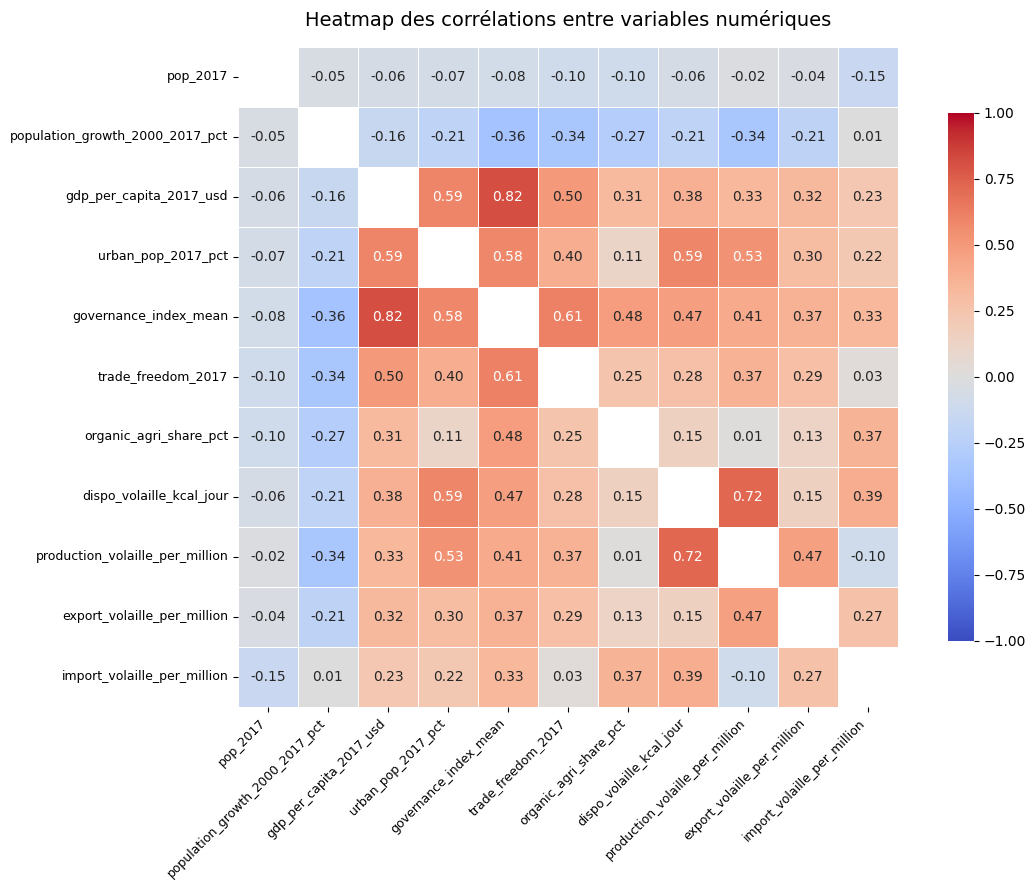

In [28]:
# Heatmap des corrélations
# On masque la diagonale (corrélation d'une variable avec elle-même = toujours 1, pas utile)
import numpy as np

# Créer un masque True sur la diagonale uniquement
masque_diagonale = np.eye(len(corr_matrix), dtype=bool)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    mask=masque_diagonale,   # on cache les cases diagonales (valeur = 1)
    annot=True,              # affiche les valeurs dans les cases
    fmt=".2f",               # format à 2 décimales
    cmap="coolwarm",         # rouge = corrélation positive forte, bleu = négative
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Heatmap des corrélations entre variables numériques", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


In [29]:
# Identification des paires fortement corrélées (|r| > 0.85)
SEUIL = 0.85

paires_fortes = []
for i in range(len(cols_num)):
    for j in range(i + 1, len(cols_num)):   # on évite les doublons et la diagonale
        r = corr_matrix.iloc[i, j]
        if abs(r) >= SEUIL:
            paires_fortes.append({
                "Variable 1": cols_num[i],
                "Variable 2": cols_num[j],
                "Corrélation": round(r, 3)
            })

if paires_fortes:
    df_paires = pd.DataFrame(paires_fortes).sort_values("Corrélation", key=abs, ascending=False)
    print(f"⚠️  Paires avec |r| ≥ {SEUIL} :")
    display(df_paires)
else:
    print(f"✅ Aucune paire avec |r| ≥ {SEUIL} — pas de redondance forte détectée.")

✅ Aucune paire avec |r| ≥ 0.85 — pas de redondance forte détectée.


### Décision : quelles variables retirer ?

Si une paire dépasse le seuil de 0.85, on retire la variable **la moins directement liée
à notre problématique** (exportations de poulet bio) :

- Si `pop_2017` et `population_growth_2000_2017_pct` sont trop corrélées → on garde `population_growth_2000_2017_pct` (plus informative sur la dynamique).
- Si `production_volaille_per_million` et `dispo_volaille_kcal_jour` sont trop corrélées → on garde `dispo_volaille_kcal_jour` (mesure la consommation réelle, plus pertinente pour un exportateur).

La cellule suivante applique la décision automatiquement en fonction des résultats réels.

In [30]:
# On supprime les variables qui sont trop corrélées à une autre
# La décision est prise manuellement à partir des résultats de la heatmap ci-dessus

variables_a_retirer = []

# Parcourir les paires fortement corrélées
for _, row in df_paires.iterrows() if paires_fortes else iter([]):
    v1 = row["Variable 1"]
    v2 = row["Variable 2"]
    r  = row["Corrélation"]
    print(f"Paire détectée : {v1} ↔ {v2}  (r = {r:.2f})")

    # Si pop_2017 est corrélée avec le taux de croissance, on retire pop_2017
    if "pop_2017" in [v1, v2] and ("growth" in v1 or "growth" in v2):
        variables_a_retirer.append("pop_2017")
        print("  → On retire pop_2017 (redondante avec le taux de croissance)")

    # Si production volaille et dispo kcal sont corrélées, on retire production
    if "production_volaille_per_million" in [v1, v2] and ("dispo" in v1 or "dispo" in v2):
        variables_a_retirer.append("production_volaille_per_million")
        print("  → On retire production_volaille_per_million (redondante avec dispo kcal)")

# Éviter les doublons dans la liste
variables_a_retirer = list(set(variables_a_retirer))

# Supprimer les colonnes identifiées
if variables_a_retirer:
    for v in variables_a_retirer:
        if v in df_clean.columns:
            df_clean = df_clean.drop(columns=[v])
    print(f"✅ Variables retirées : {variables_a_retirer}")
else:
    print("✅ Aucune variable retirée — toutes suffisamment indépendantes.")

print(f"\nDataset final : {df_clean.shape[0]} pays × {df_clean.shape[1]} variables")


✅ Aucune variable retirée — toutes suffisamment indépendantes.

Dataset final : 137 pays × 12 variables


---
## 12) Récapitulatif et vérifications finales

| Variable | Source | Description |
|---|---|---|
| `pop_2017` | FAO | Population en 2017 (habitants) |
| `population_growth_2000_2017_pct` | FAO ⚙️ | Croissance démographique 2000–2017 (%) |
| `gdp_per_capita_2017_usd` | Banque Mondiale | PIB par habitant (USD) |
| `urban_pop_2017_pct` | Banque Mondiale | Part de la population urbaine (%) |
| `governance_index_mean` | Banque Mondiale | Indice de gouvernance moyen |
| `trade_freedom_2017` | Heritage Foundation | Score de liberté du commerce |
| `organic_agri_share_pct` | FiBL | Part de l'agriculture biologique (%) |
| `dispo_volaille_kcal_jour` | FAO | Disponibilité alimentaire volaille (kcal/jour) |
| `production_volaille_per_million` | FAO ⚙️ | Production volaille / million d'hab. |
| `export_volaille_per_million` | FAO ⚙️ | Export volaille / million d'hab. (0 = non-exportateur) |
| `import_volaille_per_million` | FAO ⚙️ | Import volaille / million d'hab. |

⚙️ = variable créée par feature engineering

In [31]:
cols_modele = df_clean.select_dtypes(include="number").columns.tolist()

print("=== VÉRIFICATIONS FINALES (critères fiche d'auto-évaluation) ===")
print()

# ✅ Critère : ≥ 100 pays
n_pays = df_clean.shape[0]
assert n_pays >= 100, f"❌ {n_pays} pays — minimum 100 requis"
print(f"✅ Nombre de pays    : {n_pays}  (requis : ≥ 100)")

# ✅ Critère : ≥ 8 variables dans le modèle
n_vars = len(cols_modele)
assert n_vars >= 8, f"❌ {n_vars} variables — minimum 8 requis"
print(f"✅ Variables modèle  : {n_vars}  (requis : ≥ 8)")

# ✅ Critère : aucune valeur manquante
n_nan = df_clean.isna().sum().sum()
assert n_nan == 0, f"❌ {n_nan} valeurs manquantes restantes"
print(f"✅ Valeurs manquantes: {n_nan}  (requis : 0)")

# ✅ Critère : ≥ 3 nouvelles variables (feature engineering)
nouvelles_vars = ["population_growth_2000_2017_pct",
                  "production_volaille_per_million",
                  "export_volaille_per_million",
                  "import_volaille_per_million"]
nouvelles_presentes = [v for v in nouvelles_vars if v in df_clean.columns]
assert len(nouvelles_presentes) >= 3, f"❌ Seulement {len(nouvelles_presentes)} nouvelles variables"
print(f"✅ Feature engineering : {len(nouvelles_presentes)} nouvelles variables (requis : ≥ 3)")

print()
print("Variables du modèle :")
for v in cols_modele:
    print(f"  - {v}")

=== VÉRIFICATIONS FINALES (critères fiche d'auto-évaluation) ===

✅ Nombre de pays    : 137  (requis : ≥ 100)
✅ Variables modèle  : 11  (requis : ≥ 8)
✅ Valeurs manquantes: 0  (requis : 0)
✅ Feature engineering : 4 nouvelles variables (requis : ≥ 3)

Variables du modèle :
  - pop_2017
  - population_growth_2000_2017_pct
  - gdp_per_capita_2017_usd
  - urban_pop_2017_pct
  - governance_index_mean
  - trade_freedom_2017
  - organic_agri_share_pct
  - dispo_volaille_kcal_jour
  - production_volaille_per_million
  - export_volaille_per_million
  - import_volaille_per_million


In [32]:
# Statistiques descriptives finales
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
pop_2017,137.0,5.142e+07,1.705e+08,71458.000,4.107e+06,1.118e+07,3.673e+07,1.421e+09
population_growth_2000_2017_pct,137.0,2.851e+01,2.962e+01,-18.745,8.495e+00,2.357e+01,4.557e+01,2.027e+02
gdp_per_capita_2017_usd,137.0,1.490e+04,2.001e+04,470.939,1.964e+03,5.955e+03,1.863e+04,1.102e+05
urban_pop_2017_pct,137.0,6.008e+01,2.196e+01,16.350,4.295e+01,6.130e+01,7.856e+01,1.000e+02
governance_index_mean,137.0,5.230e-02,8.224e-01,-1.608,-5.740e-01,-1.722e-01,6.507e-01,1.835e+00
trade_freedom_2017,137.0,7.791e+01,9.143e+00,50.600,7.060e+01,8.000e+01,8.700e+01,9.000e+01
organic_agri_share_pct,137.0,3.044e+00,5.573e+00,0.000,1.000e-01,5.000e-01,3.360e+00,3.760e+01
dispo_volaille_kcal_jour,137.0,7.085e+01,5.331e+01,0.000,2.200e+01,6.500e+01,1.030e+02,2.340e+02
production_volaille_per_million,137.0,1.814e+01,1.756e+01,0.000,3.168e+00,1.389e+01,2.699e+01,7.630e+01
export_volaille_per_million,137.0,3.656e+00,9.876e+00,0.000,0.000e+00,8.934e-02,3.016e+00,8.331e+01


In [33]:
# Pays sans production locale de volaille (non-producteurs → opportunités d'export)
pays_zero = df_clean[
    df_clean["production_volaille_per_million"] == 0
][["country", "pop_2017", "import_volaille_per_million", "export_volaille_per_million"]]

print(f"🔍 Pays sans production locale de volaille : {len(pays_zero)}")
display(pays_zero.sort_values("pop_2017", ascending=False))
print("→ Ces pays importent sans produire — opportunités directes pour La Poule Qui Chante.")

🔍 Pays sans production locale de volaille : 4


,country,pop_2017,import_volaille_per_million,export_volaille_per_million
183,Îles Salomon,636039.0,9.433,0.000
123,Luxembourg,591910.0,18.584,1.689
228,Samoa,195352.0,87.022,0.000
55,Dominique,71458.0,55.977,0.000


→ Ces pays importent sans produire — opportunités directes pour La Poule Qui Chante.


---
## 13) Export du dataset final

In [34]:
df_clean.to_csv("P11_dataset_final_pour_acp.csv", index=False, encoding="utf-8")
print(f"💾 Exporté : P11_dataset_final_pour_acp.csv")
print(f"   {df_clean.shape[0]} pays × {df_clean.shape[1]} variables — prêt pour l'ACP et le clustering")

💾 Exporté : P11_dataset_final_pour_acp.csv
   137 pays × 12 variables — prêt pour l'ACP et le clustering


---
## Synthèse

| Étape | Action | Résultat |
|---|---|---|
| 1–2 | Chargement des 7 CSV | Données disponibles en mémoire |
| 3 | Nettoyage (types, doublons, espaces) | Données homogènes |
| 4 | Exploration FAO volaille | 4 indicateurs extraits |
| 5 | Feature engineering — croissance démo. | 1ère nouvelle variable |
| 6 | Fusion de toutes les sources | Dataset unifié |
| 7 | **Imputation export NaN → 0** | Données complètes, hypothèse justifiée |
| 8 | Statistiques descriptives + outliers | Distribution comprise |
| 9 | Filtrage strict (0 NaN) | **≥ 100 pays** conservés ✅ |
| 10 | Feature engineering — indicateurs/hab. | 3 nouvelles variables (total : 4) |
| 11 | **Heatmap corrélations + retrait redondances** | **≥ 8 variables** indépendantes ✅ |
| 12–13 | Vérifications finales + export | Prêt pour l'ACP |

**Prochain notebook** : Centrage-réduction, ACP, cercle des corrélations, CAH et KMeans.